* IMPORT NECESSARY LIBRARIES

In [44]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from services import outliers, num_isnull

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report , f1_score , roc_curve, auc

%matplotlib inline

* Getting the dataset from UCI

In [2]:
from ucimlrepo import fetch_ucirepo 
  

heart_disease = fetch_ucirepo(id=45) 
  

X = heart_disease.data.features 
y = heart_disease.data.targets 
  
print(heart_disease.variables) 


        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

In [3]:
df = heart_disease.data.original

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
df.describe

<bound method NDFrame.describe of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
0        3  0.0   6.0   

In [5]:
print ( '1-cp is chest pain from ' , df['cp'].min() , ' to ' , df['cp'].max() , 
      '\n2-trestbps is Resting Blood Pressure which its mean is ', df['trestbps'].mean(),
      '\n3-fbs is Fasting Blood Sugar which if value > 120 = 1 , else value = 0. Currency of it' , df['fbs'].value_counts(),
      '\n4-restecg is Resting ECG results'
      '\n5-exangexang (Exercise induced angina)'
      '\n6-oldpeakoldpeak (ST depression)'
      '\n7-slope (Slope of the peak exercise ST segment)'
      '\n8-ca is Number of vessels that appeared in the contrast X-ray (from 0 to 3)'
      '\n9- num is the diagnose from 0 to 4')


1-cp is chest pain from  1  to  4 
2-trestbps is Resting Blood Pressure which its mean is  131.68976897689768 
3-fbs is Fasting Blood Sugar which if value > 120 = 1 , else value = 0. Currency of it fbs
0    258
1     45
Name: count, dtype: int64 
4-restecg is Resting ECG results
5-exangexang (Exercise induced angina)
6-oldpeakoldpeak (ST depression)
7-slope (Slope of the peak exercise ST segment)
8-ca is Number of vessels that appeared in the contrast X-ray (from 0 to 3)
9- num is the diagnose from 0 to 4


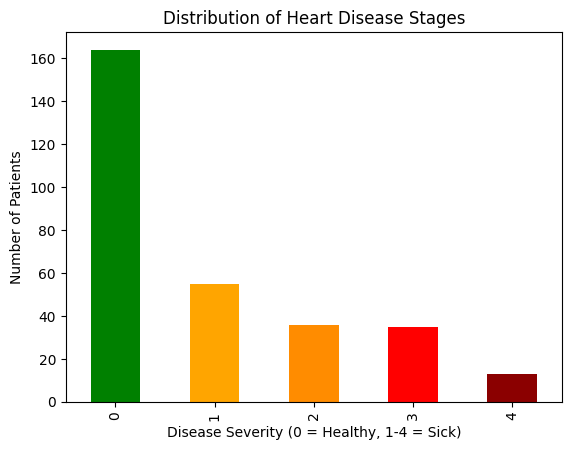

In [6]:
df['num'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'darkorange', 'red', 'darkred'])

plt.title('Distribution of Heart Disease Stages')
plt.xlabel('Disease Severity (0 = Healthy, 1-4 = Sick)')
plt.ylabel('Number of Patients')

plt.show()

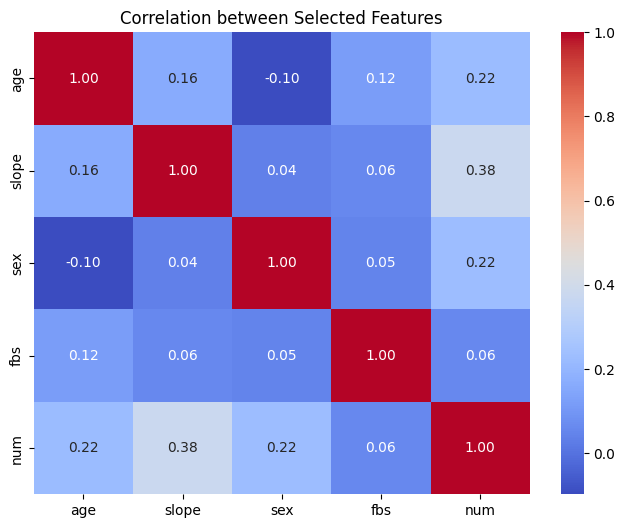

In [7]:
selected_features = ['age', 'slope', 'sex', 'fbs', 'num']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 


plt.title('Correlation between Selected Features')
plt.show()

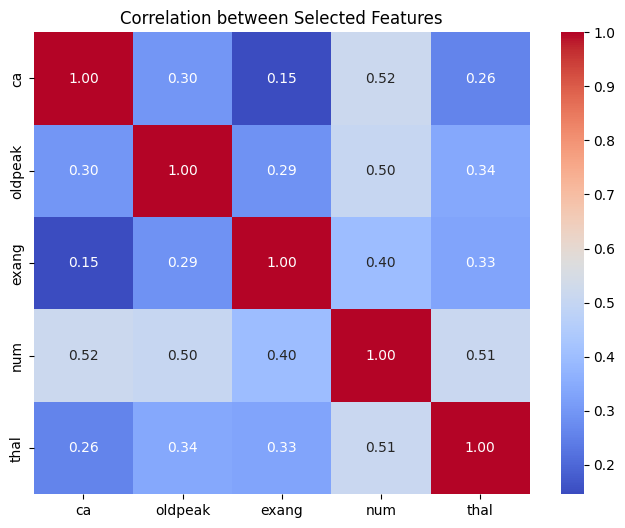

In [8]:
selected_features = ['ca', 'oldpeak', 'exang', 'num' , 'thal']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 


plt.title('Correlation between Selected Features')
plt.show()

In [ ]:

print(num_isnull(df))

# as null values are small numbers of row so i chosse to drop them (C = 4 , THAL = 2 )

df.dropna(inplace=True)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [45]:
print(num_isnull(df))

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [ ]:

df = outliers(df , 'chol')
df = outliers (df , 'thalach')
df = outliers(df , 'trestbps')

Number of outliers in chol column was 5
Number of outliers in thalach column was 1
Number of outliers in trestbps column was 9


# MODEL BULIDING USING SVM 


In [33]:
X = df.drop('num', axis=1)
Y = (df['num'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [35]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [40]:
y_pred = svm_model.predict(X_test_scaled)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.87        61
           1       0.88      0.81      0.84        52

    accuracy                           0.86       113
   macro avg       0.86      0.85      0.86       113
weighted avg       0.86      0.86      0.86       113



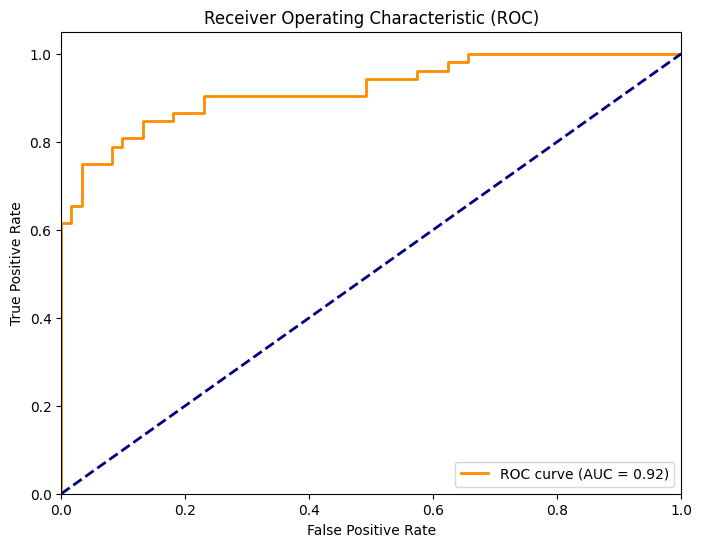

In [ ]:
y_scores = svm_model.decision_function(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()